# Rebuild: Tempo Curve Reconstruction (Processed Tempo)
Uses processed tempo curves + consensus boundaries, then compares against predicted boundaries/strengths.


In [67]:
# Cell 1: imports
from pathlib import Path
import random
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

from build_mazurka_beat_npz_performer_levels import (
    load_beat_time,
    compute_tempo_curves,
    group_analysis_hierarchy,
)


In [68]:
# Cell 2: parameters (edit here)
piece_id = "M06-2"
pred_csv = Path("out/M06-2_all_levels_pred_strengths.csv")
data_dir = Path("beat_data_mazurka_performer_levels")
beat_time_dir = Path("../../MazurkaBL-master/beat_time")  # relative to MERIX SUBMISSION/MIREX_Model
config_path = Path("config_beat_mazurka_level6.yaml")
levels = [1, 2, 3, 4, 5, 6]
str_vec = [3, 2, 2, 2, 2, 2]
thr = 0.3  # consensus threshold across performers
smooth_window = 3
bpm_range = (0, 5000)
clip_max = 600


In [69]:
# Cell 3: helpers
def parse_pred_strengths_csv(path: Path):
    rows = {}
    import csv
    with path.open("r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            level = int(row["level"])
            pos_str = row["pred_peak_positions"].strip()
            strength_str = row["pred_peak_strengths_scaled"].strip()
            positions = np.array([int(x) for x in pos_str.split()] if pos_str else [], dtype=int)
            strengths = np.array([float(x) for x in strength_str.split()] if strength_str else [], dtype=float)
            rows[level] = (positions, strengths)
    return rows

def list_pieces_from_beat_time(beat_time_dir: Path):
    pieces = []
    for p in beat_time_dir.glob("*beat_time.csv"):
        name = p.stem.replace("beat_time", "")
        pieces.append(name)
    return sorted(set(pieces))

def list_pieces_from_npz(data_dir: Path, levels):
    pieces = set()
    for lv in levels:
        for p in data_dir.glob(f"*_L{lv}.npz"):
            stem = p.stem
            if "_" in stem:
                piece = stem.split("_")[0]
                pieces.add(piece)
    return sorted(pieces)

def split_train_val(pieces, train_split, seed):
    rng = random.Random(seed)
    pieces = list(pieces)
    rng.shuffle(pieces)
    n_train = max(1, int(len(pieces) * train_split))
    n_train = min(n_train, len(pieces) - 1) if len(pieces) > 1 else len(pieces)
    return pieces[:n_train], pieces[n_train:]

def load_piece_mean_tempo(beat_time_dir, piece_id, smooth_window=3, bpm_range=(0, 5000), clip_max=600):
    f = beat_time_dir / f"{piece_id}beat_time.csv"
    df_bt, performer_cols = load_beat_time(f)
    tempo_arrays = compute_tempo_curves(
        df_bt, performer_cols, smooth_window=smooth_window, bpm_range=bpm_range, clip_max=clip_max
    )
    names = list(tempo_arrays.keys())
    mat = np.vstack([tempo_arrays[nm] for nm in names])
    mean_tempo = np.nanmean(mat, axis=0)
    return mean_tempo, tempo_arrays, names

def consensus_level_sets(tempo_arrays, str_vec, thr=0.3, enforce_nested=True):
    names = list(tempo_arrays.keys())
    P = len(names)
    N = len(next(iter(tempo_arrays.values())))
    L = len(str_vec)
    counts = np.zeros((L, N), dtype=int)
    for nm in names:
        _, level_sets_nm = group_analysis_hierarchy(tempo_arrays[nm], str_vec, enforce_nested=enforce_nested)
        for l in range(1, L + 1):
            idx = np.asarray(level_sets_nm[l], dtype=int)
            idx = idx[(idx >= 0) & (idx < N)]
            counts[l - 1, idx] += 1
    freq = counts / max(P, 1)
    level_sets = {}
    for l in range(1, L + 1):
        idx = np.where(freq[l - 1] >= thr)[0]
        level_sets[l] = idx.astype(int)
    if enforce_nested:
        cum = np.zeros(N, dtype=bool)
        nested = {}
        for l in range(L, 0, -1):
            cur = np.zeros(N, dtype=bool)
            cur[level_sets[l]] = True
            cum |= cur
            nested[l] = np.where(cum)[0]
        level_sets = nested
    return level_sets, freq

def build_level_basis(N, boundaries, strengths=None):
    b = np.asarray(boundaries, dtype=int)
    b = b[(b >= 0) & (b < N)]
    b = np.unique(b)
    if b.size == 0:
        b = np.array([0, N - 1], dtype=int)
    if b[0] != 0:
        b = np.insert(b, 0, 0)
    if b[-1] != N - 1:
        b = np.append(b, N - 1)
    b.sort()

    if strengths is None or len(strengths) == 0:
        s = np.ones(len(b), dtype=float)
    else:
        s = np.zeros(len(b), dtype=float)
        orig_b = np.asarray(boundaries, dtype=int)
        orig_s = np.asarray(strengths, dtype=float)
        for i, bi in enumerate(b):
            if orig_b.size == 0:
                s[i] = 1.0
            else:
                j = int(np.argmin(np.abs(orig_b - bi)))
                s[i] = orig_s[j]
    f = np.zeros(N, dtype=float)
    for i in range(len(b) - 1):
        s0, s1 = s[i], s[i + 1]
        amp = 0.5 * (s0 + s1)
        a = int(b[i])
        c = int(b[i + 1])
        if c <= a:
            continue
        Lseg = c - a
        t = np.arange(a, c + 1)
        u = (t - a) / Lseg
        dip = -4.0 * u * (1.0 - u)
        f[t] = amp * dip
    return f

def build_design_matrix(N, level_sets, L, strengths_by_level=None):
    cols = [np.ones(N, dtype=float)]
    for l in range(1, L + 1):
        strengths = None
        if strengths_by_level is not None and l in strengths_by_level:
            strengths = strengths_by_level[l]
        cols.append(build_level_basis(N, level_sets[l], strengths=strengths))
    X = np.stack(cols, axis=1)
    return X

def apply_params(mean_tempo, level_sets, beta, L, strengths_by_level=None):
    N = len(mean_tempo)
    X = build_design_matrix(N, level_sets, L, strengths_by_level=strengths_by_level)
    y_hat = X @ beta
    y = np.asarray(mean_tempo, dtype=float)
    rmse = float(np.sqrt(np.mean((y_hat - y) ** 2)))
    corr = float(np.corrcoef(y, y_hat)[0, 1])
    return y_hat, {"rmse": rmse, "corr": corr}

def plot_recon(y, y_hat, title="", max_beats=400):
    n = min(len(y), max_beats)
    plt.figure(figsize=(14, 4))
    plt.plot(y[:n], alpha=0.9, linewidth=1.3, label="mean tempo")
    plt.plot(y_hat[:n], alpha=0.9, linewidth=1.3, label="reconstructed")
    plt.xlabel("Score beat index")
    plt.ylabel("Tempo (BPM)")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


In [70]:
# Cell 4: fit params on training pieces (consensus boundaries)
cfg = yaml.safe_load(config_path.read_text())
train_split = cfg.get("data", {}).get("train_split", 0.8)
seed = cfg.get("training", {}).get("seed", 42)

pieces_bt = set(list_pieces_from_beat_time(beat_time_dir))
pieces_npz = set(list_pieces_from_npz(data_dir, levels))
pieces = sorted(pieces_bt & pieces_npz)
train_pieces, val_pieces = split_train_val(pieces, train_split, seed)
print("train pieces:", len(train_pieces), "val pieces:", len(val_pieces))

X_list, y_list = [], []
for pid in train_pieces:
    y, tempo_arrays, _ = load_piece_mean_tempo(
        beat_time_dir, pid, smooth_window=smooth_window, bpm_range=bpm_range, clip_max=clip_max
    )
    level_sets, _ = consensus_level_sets(tempo_arrays, str_vec, thr=thr, enforce_nested=True)
    N = len(y)
    X = build_design_matrix(N, level_sets, len(str_vec))
    X_list.append(X)
    y_list.append(y)

if not X_list:
    raise RuntimeError("No training data found for fitting weights")
X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)
beta, *_ = np.linalg.lstsq(X_all, y_all, rcond=None)
print("beta = [c, A1..A6]:", beta)


train pieces: 35 val pieces: 9
beta = [c, A1..A6]: [ 85.44487538 -10.06690624 -20.79476442 -21.56947438 -14.25856039
  -6.31970582 -19.50028894]


In [71]:
# Cell 5: reconstruct with TRUE boundaries (consensus)
y_true, tempo_arrays, _ = load_piece_mean_tempo(
    beat_time_dir, piece_id, smooth_window=smooth_window, bpm_range=bpm_range, clip_max=clip_max
)
level_sets_true, _ = consensus_level_sets(tempo_arrays, str_vec, thr=thr, enforce_nested=True)
y_true_hat, met_true = apply_params(y_true, level_sets_true, beta, len(str_vec))
print("true metrics:", met_true)


true metrics: {'rmse': 18.627645966832205, 'corr': 0.8822175931206393}


In [72]:
# Cell 6: reconstruct with PRED boundaries + strengths
pred_map = parse_pred_strengths_csv(pred_csv)
level_sets_pred = {}
strengths_by_level = {}
for l in range(1, len(str_vec) + 1):
    pos, strengths = pred_map.get(l, (np.array([], dtype=int), np.array([], dtype=float)))
    level_sets_pred[l] = pos
    strengths_by_level[l] = strengths

y_pred_hat, met_pred = apply_params(
    y_true, level_sets_pred, beta, len(str_vec), strengths_by_level=strengths_by_level
)
print("pred metrics:", met_pred)


pred metrics: {'rmse': 17.37965918918674, 'corr': 0.715415200037442}


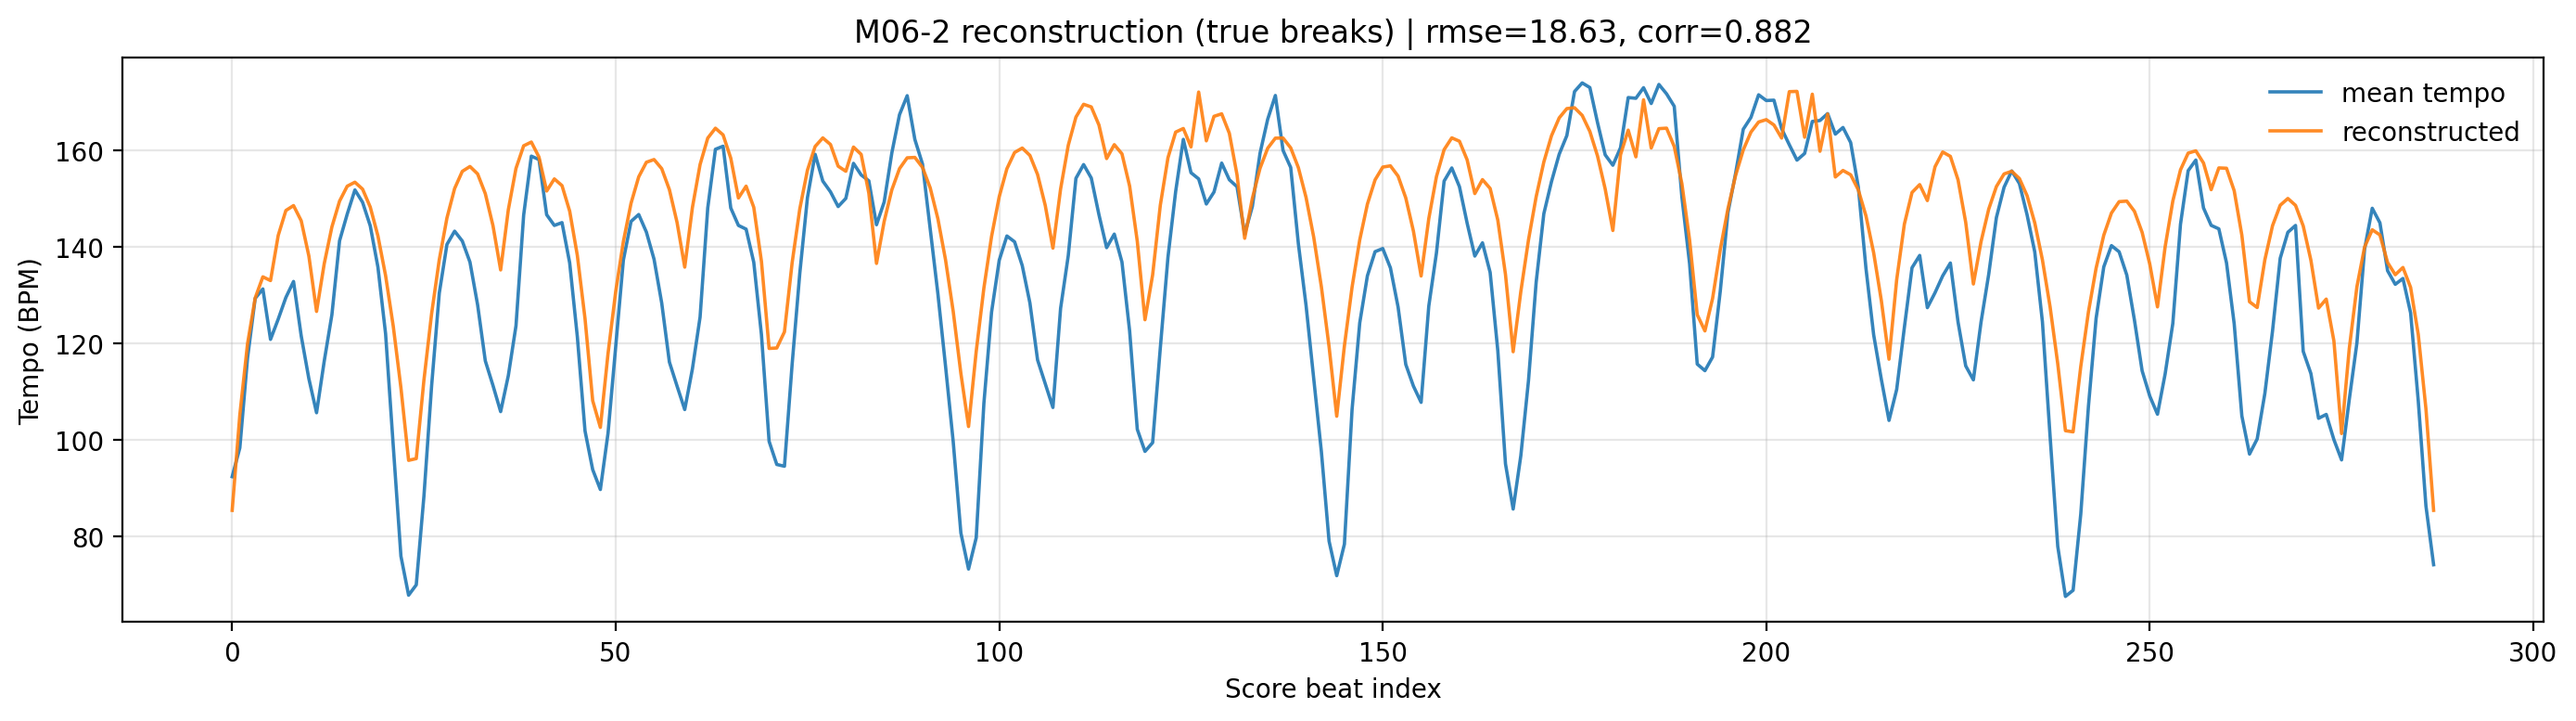

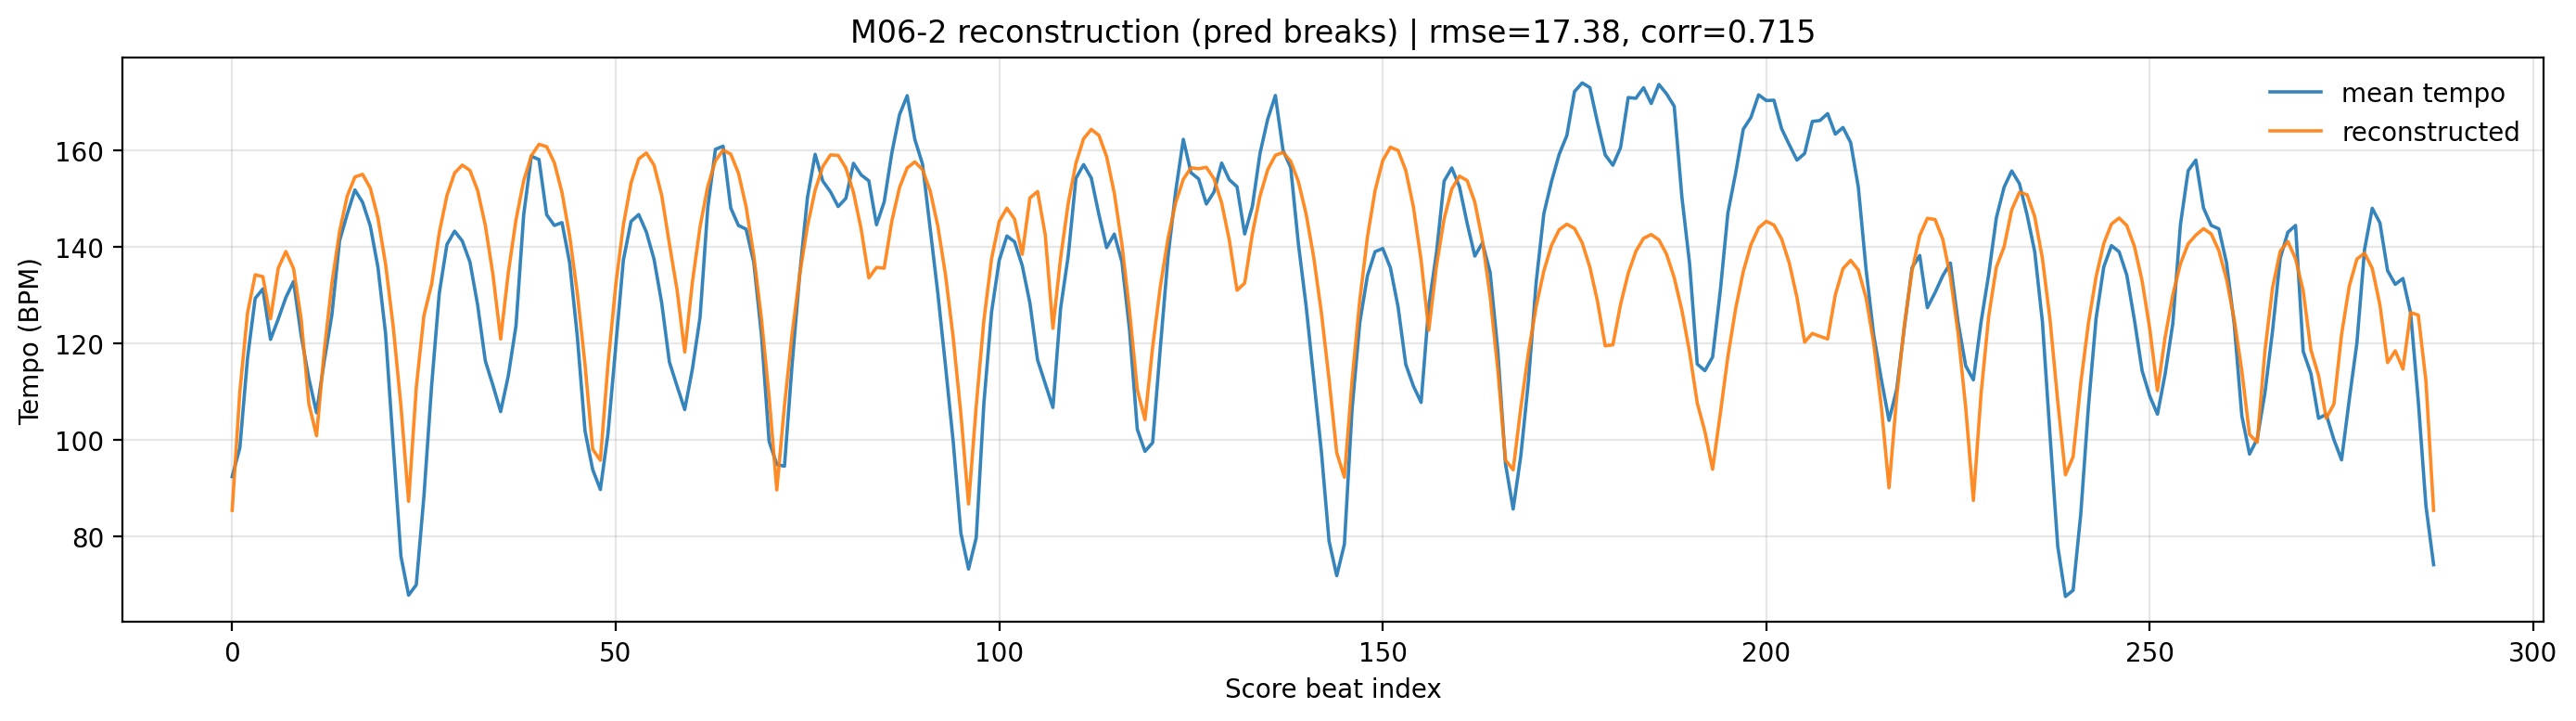

In [73]:
# Cell 7: plots
plot_recon(y_true, y_true_hat, title=f"{piece_id} reconstruction (true breaks) | rmse={met_true['rmse']:.2f}, corr={met_true['corr']:.3f}")
plot_recon(y_true, y_pred_hat, title=f"{piece_id} reconstruction (pred breaks) | rmse={met_pred['rmse']:.2f}, corr={met_pred['corr']:.3f}")


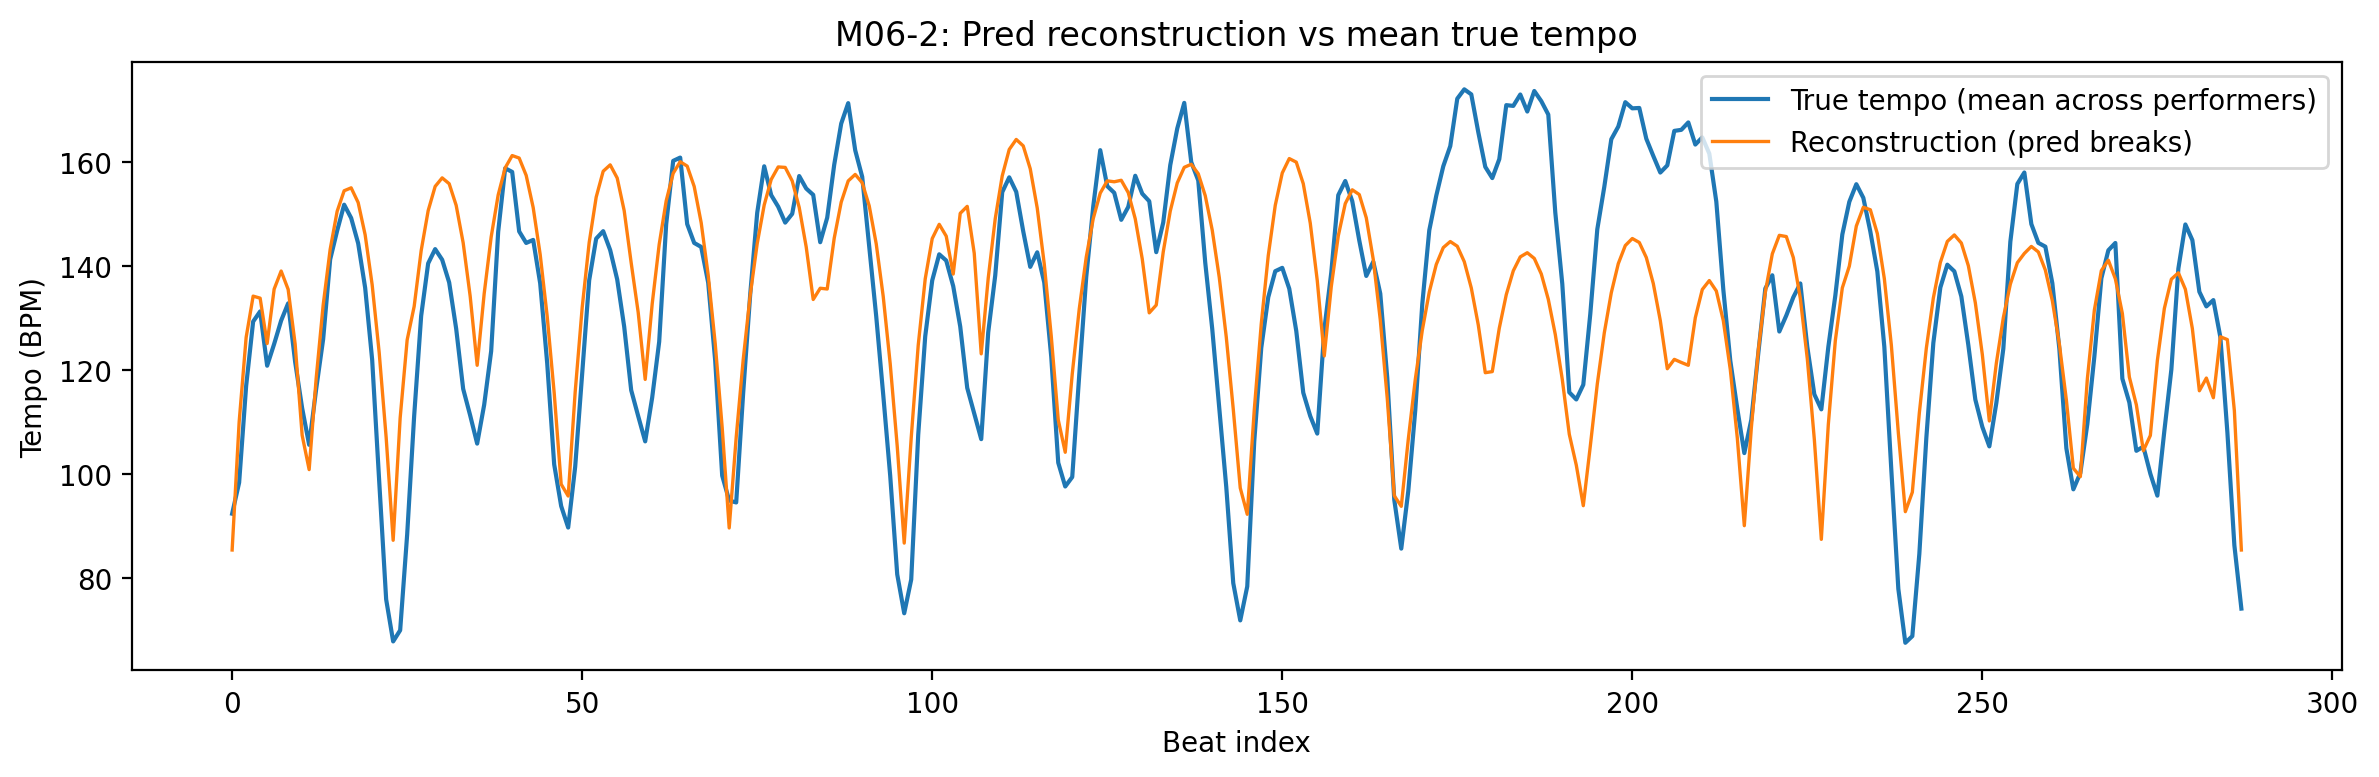

In [74]:
# Cell: pred reconstruction vs mean true tempo (all performers)
plt.figure(figsize=(12, 4))
plt.plot(y_true, label="True tempo (mean across performers)", linewidth=1.5)
plt.plot(y_pred_hat, label="Reconstruction (pred breaks)", linewidth=1.2)
plt.title(f"{piece_id}: Pred reconstruction vs mean true tempo")
plt.xlabel("Beat index")
plt.ylabel("Tempo (BPM)")
plt.legend()
plt.tight_layout()
plt.show()


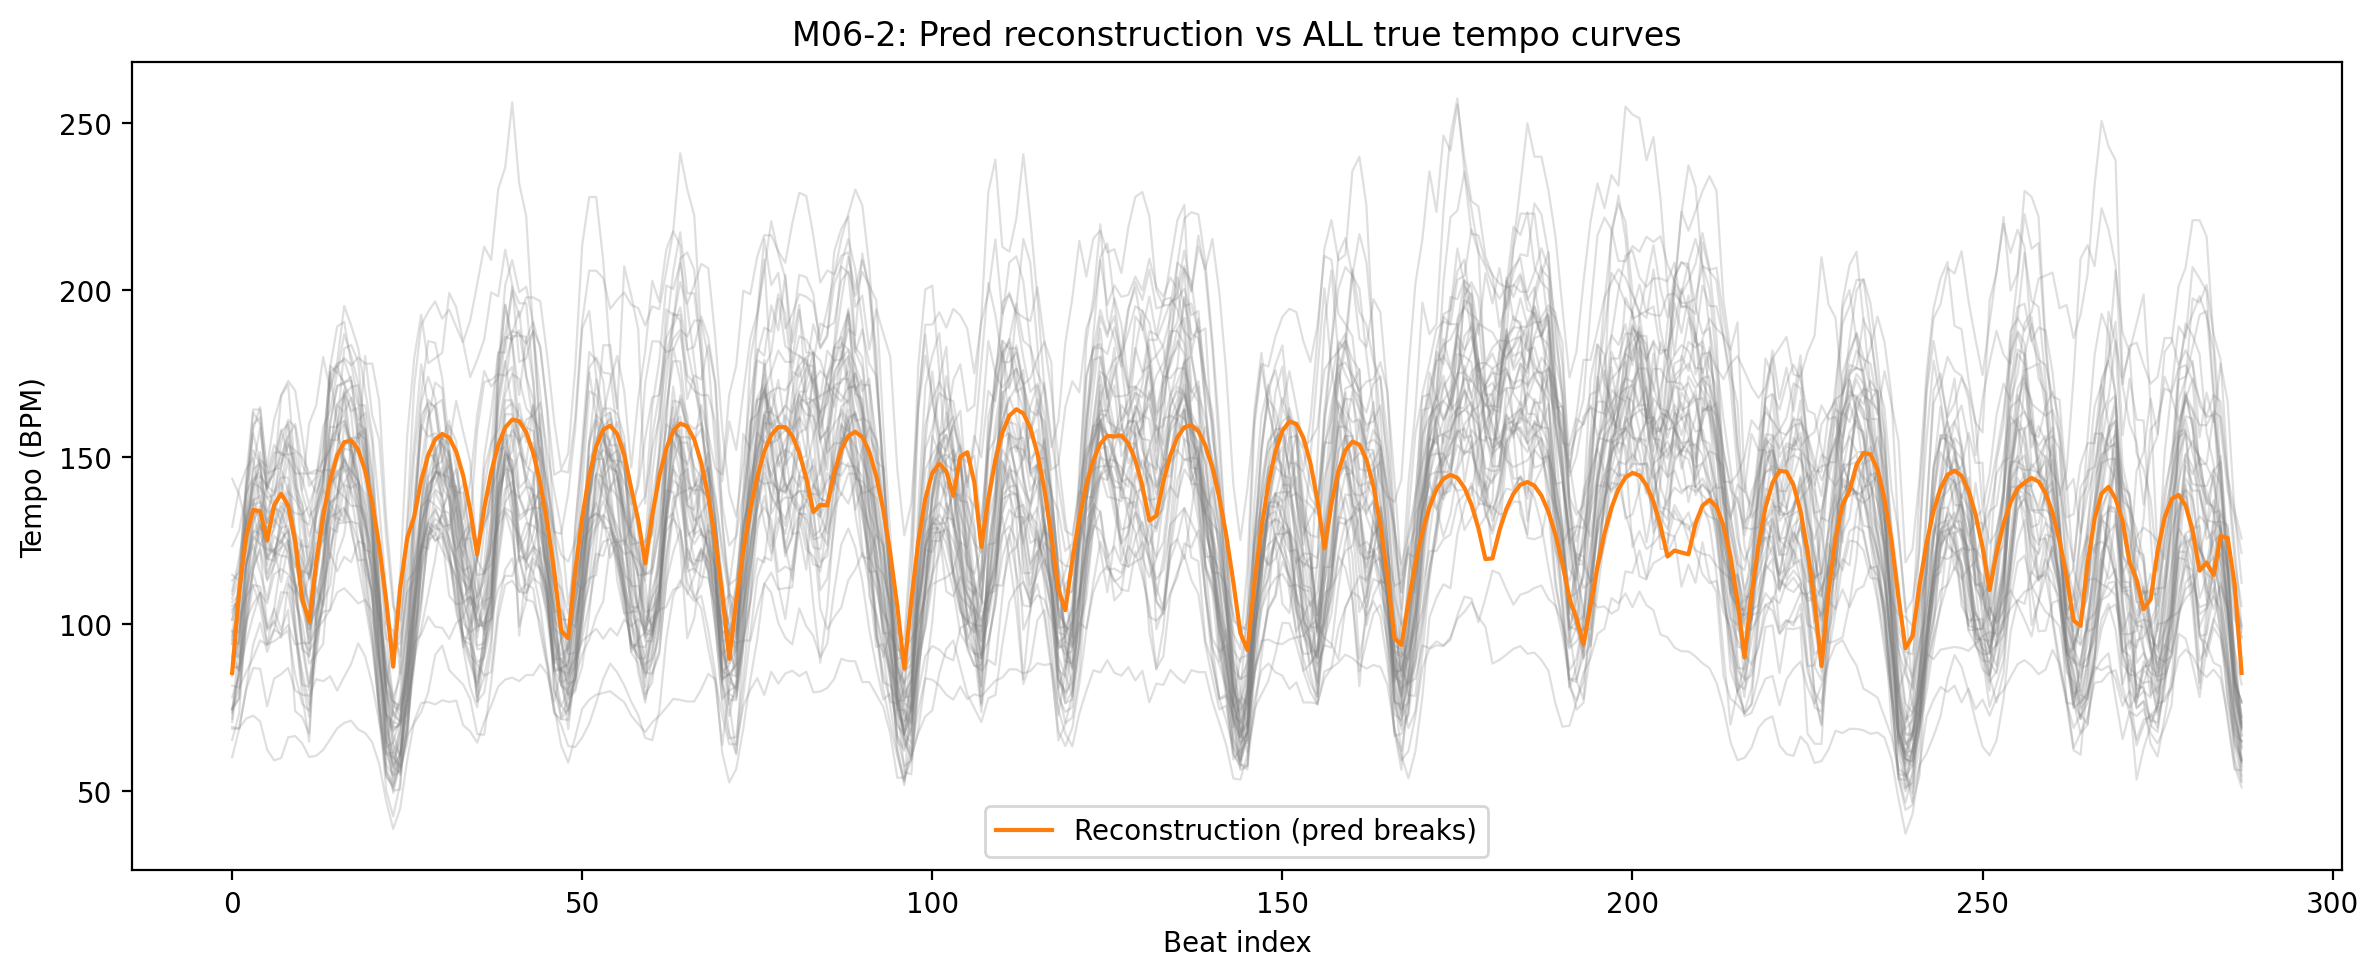

In [75]:
# Cell: pred reconstruction vs ALL performers' true tempo curves
max_performers = None  # 不限制 = 全部；或设成 20 只画前 20 个
alpha = 0.25           # 真实曲线透明度
lw_true = 0.8
lw_pred = 1.5

plt.figure(figsize=(12, 5))
names = list(tempo_arrays.keys())
if max_performers is not None:
    names = names[:max_performers]

for nm in names:
    plt.plot(tempo_arrays[nm], color="gray", alpha=alpha, linewidth=lw_true)

plt.plot(y_pred_hat, color="C1", linewidth=lw_pred, label="Reconstruction (pred breaks)")
plt.title(f"{piece_id}: Pred reconstruction vs ALL true tempo curves")
plt.xlabel("Beat index")
plt.ylabel("Tempo (BPM)")
plt.legend()
plt.tight_layout()
plt.show()
